# DATA WRANGLING

In [50]:
import pandas as pd

jobs_df = pd.read_csv("dataset/jobs.csv")
skills_df = pd.read_csv("dataset/skills.csv")
resume_df = pd.read_csv("dataset/resume.csv")

In [51]:
jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Job Title              324 non-null    object
 1   Category               324 non-null    object
 2   Education Requirement  324 non-null    object
 3   Experience Years       324 non-null    int64 
 4   Required Skills        324 non-null    object
 5   Salary Range           324 non-null    object
dtypes: int64(1), object(5)
memory usage: 15.3+ KB


In [52]:
skills_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Skill Name  120 non-null    object
 1   Category    120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [53]:
resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Resume ID         10000 non-null  object
 1   Resume Text       10000 non-null  object
 2   Education         10000 non-null  object
 3   Experience Years  10000 non-null  int64 
 4   Skills            10000 non-null  object
 5   Job Role          10000 non-null  object
 6   Category          10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [54]:
# Normalize semua text (spasi, huruf kapital/kecil)
jobs_df = jobs_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
skills_df = skills_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
resume_df = resume_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)

C:\Users\hp\AppData\Local\Temp\ipykernel_15720\1157588541.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  jobs_df = jobs_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\hp\AppData\Local\Temp\ipykernel_15720\1157588541.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  skills_df = skills_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\hp\AppData\Local\Temp\ipykernel_15720\1157588541.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  resume_df = resume_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [55]:
# Merapikan nama kolom
jobs_df.columns = jobs_df.columns.str.lower().str.replace(" ", "_")
skills_df.columns = skills_df.columns.str.lower().str.replace(" ", "_")
resume_df.columns = resume_df.columns.str.lower().str.replace(" ", "_")

In [56]:
# Cleaning skills (dari resume.csv)
def clean_skills(text):
    text = text.replace("[","").replace("]","").replace("'","")
    skills = text.split(",")
    return [s.strip() for s in skills if s.strip() != ""]

resume_df['skills'] = resume_df['skills'].apply(clean_skills)

In [57]:
# Cleaning skills (dari jobs.csv)
jobs_df['required_skills'] = jobs_df['required_skills'].apply(clean_skills)

In [58]:
# Samakan nama kolom untuk job di jobs.csv dan resume.csv
jobs_df['job_title'] = jobs_df['job_title'].str.strip()
resume_df['job_role'] = resume_df['job_role'].str.strip()

In [59]:
# Cek udah cocok belum (kalau kosong -> job sudah match)
set(resume_df['job_role']) - set(jobs_df['job_title'])

set()

In [60]:
# Normalisasi singkatan jurusan
import re
def clean_education_v2(text):
    text = text.lower()
    
    mapping = {
        "it": "information technology",
        "rn": "nursing",
        "mba": "business administration",
        "mpa": "public administration",
        "hr": "human resources",
        "cpa": "accounting",
        "qa": "quality assurance",
        "ai": "artificial intelligence",
        "pt": "physical therapy"
    }
    
    for k, v in mapping.items():
        text = re.sub(rf'\b{k}\b', v, text)
    
    return text.strip()

resume_df['education_clean_v2'] = resume_df['education'].apply(clean_education_v2)
jobs_df['education_clean_v2'] = jobs_df['education_requirement'].apply(clean_education_v2)

In [61]:
# Drop kolom lama education dan ganti dengan yang baru
resume_df = resume_df.drop(columns=['education'])
resume_df = resume_df.rename(columns={'education_clean_v2': 'education'})

jobs_df = jobs_df.drop(columns=['education_requirement'])
jobs_df = jobs_df.rename(columns={'education_clean_v2': 'education_requirement'})

In [62]:
# Cek apakah sudah terganti
resume_df.head(10)

,resume_id,resume_text,experience_years,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,2,[market research|maven|java|rest api|spring bo...,java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,3,[agile|data analysis|precision|problem solving...,microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,2,[react|customer service|technical knowledge|pl...,plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,0,[mysql|query optimization|symfony|terraform|ph...,php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,3,[problem solving|docker|creativity|scrum|ansib...,art director,creative & design,bachelor's in design
5,r000005,education: administrative certification experi...,2,[ci/cd|problem solving|database design|pytorch...,executive assistant,administration,administrative certification
6,r000006,education: bachelor's in computer science expe...,3,[distributed systems|cql|cassandra|performance...,cassandra developer,technology,bachelor's in computer science
7,r000007,education: bachelor's in it experience: 1 year...,1,[performance tuning|sql|etl|data integration|j...,informatica developer,data & analytics,bachelor's in information technology
8,r000008,education: pt license experience: 4 years skil...,4,[communication|swift|anatomy knowledge|exercis...,physical therapist,healthcare,physical therapy license
9,r000009,education: bachelor's in computer science expe...,5,[postgresql|distributed systems|kanban|phoenix...,elixir developer,technology,bachelor's in computer science


In [63]:
jobs_df.head(10)

,job_title,category,experience_years,required_skills,salary_range,education_requirement
0,software engineer,technology,2,[python|java|c++|git|software design|problem s...,80-150k,bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,2,[javascript|react|node.js|html/css|database|git],75-140k,diploma in information technology|bachelor's i...
2,frontend developer,technology,1,[javascript|react|vue.js|css|html|ui/ux design],70-130k,diploma in information technology|bachelor's i...
3,backend developer,technology,2,[python|java|node.js|database design|api devel...,75-135k,bachelor's in computer science
4,devops engineer,technology,3,[docker|kubernetes|aws|linux|ci/cd|scripting],85-150k,bachelor's in computer science|information tec...
5,cloud architect,technology,5,[aws|azure|gcp|system design|networking|security],120-200k,bachelor's in computer science|cloud certifica...
6,data scientist,technology,2,[python|machine learning|statistics|tensorflow...,90-160k,master's in data science|bachelor's in mathema...
7,machine learning engineer,technology,3,[python|tensorflow|pytorch|deep learning|stati...,100-180k,master's in computer science|master's in artif...
8,data engineer,technology,2,[python|spark|hadoop|sql|data warehousing|etl],85-155k,bachelor's in computer science
9,database administrator,technology,2,[sql|mongodb|database optimization|linux|backu...,70-130k,bachelor's in information technology|informati...


In [64]:
print(jobs_df['required_skills'].iloc[0])
print(type(jobs_df['required_skills'].iloc[0]))

['python|java|c++|git|software design|problem solving']
<class 'list'>


In [65]:
# Cleaning skills
def clean_skills(text):
    import pandas as pd
    
    if pd.isna(text):
        return []
    
    # kalau list
    if isinstance(text, list):
        # kalau list cuma 1 elemen → ambil isinya
        if len(text) == 1:
            text = text[0]
        else:
            return [str(s).strip().lower() for s in text]
    
    # sekarang pasti string
    text = str(text).lower()
    
    text = text.replace("[","").replace("]","")
    text = text.replace("|", ",")
    
    skills = text.split(",")
    
    return [s.strip() for s in skills if s.strip() != ""]

In [66]:
jobs_df['required_skills'] = jobs_df['required_skills'].apply(clean_skills)
resume_df['skills'] = resume_df['skills'].apply(clean_skills)

In [67]:
# Cek apakah sudah berubah jadi list di bagian required skills & skills
jobs_df.head()

,job_title,category,experience_years,required_skills,salary_range,education_requirement
0,software engineer,technology,2,"[python, java, c++, git, software design, prob...",80-150k,bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,2,"[javascript, react, node.js, html/css, databas...",75-140k,diploma in information technology|bachelor's i...
2,frontend developer,technology,1,"[javascript, react, vue.js, css, html, ui/ux d...",70-130k,diploma in information technology|bachelor's i...
3,backend developer,technology,2,"[python, java, node.js, database design, api d...",75-135k,bachelor's in computer science
4,devops engineer,technology,3,"[docker, kubernetes, aws, linux, ci/cd, script...",85-150k,bachelor's in computer science|information tec...


In [68]:
resume_df.head()

,resume_id,resume_text,experience_years,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,2,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,3,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,2,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,0,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,3,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design


In [69]:
# Hapus kolom tidak perlu
jobs_df.drop(columns=['experience_years', 'salary_range'], inplace=True)
resume_df.drop(columns=['experience_years'], inplace=True)

In [70]:
# Cek lagi tabel final
jobs_df.head()

,job_title,category,required_skills,education_requirement
0,software engineer,technology,"[python, java, c++, git, software design, prob...",bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,"[javascript, react, node.js, html/css, databas...",diploma in information technology|bachelor's i...
2,frontend developer,technology,"[javascript, react, vue.js, css, html, ui/ux d...",diploma in information technology|bachelor's i...
3,backend developer,technology,"[python, java, node.js, database design, api d...",bachelor's in computer science
4,devops engineer,technology,"[docker, kubernetes, aws, linux, ci/cd, script...",bachelor's in computer science|information tec...


In [71]:
resume_df.head()

,resume_id,resume_text,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design


In [72]:
# Sebelum dimerge, pastikan nama kolom sama
jobs_df['job_title'] = jobs_df['job_title'].str.strip().str.lower()
resume_df['job_role'] = resume_df['job_role'].str.strip().str.lower()

In [73]:
# Cek apakah sudah match apa belum (kosong berarti match)
set(resume_df['job_role']) - set(jobs_df['job_title'])

set()

In [74]:
# Merge tabel
merged_df = resume_df.merge(
    jobs_df,
    left_on='job_role',
    right_on='job_title',
    how='inner'
)

In [75]:
merged_df.head()

,resume_id,resume_text,skills,job_role,category_x,education,job_title,category_y,required_skills,education_requirement
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science,java backend developer,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology,microbiologist,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship,plumber,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science,php developer,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design,art director,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [76]:
len(merged_df)

10000

In [77]:
# Pakai kolom category dari 1 dataset saja (supaya tidak jadi x dan y)
merged_df = merged_df.drop(columns=['category_x'])
merged_df = merged_df.rename(columns={'category_y': 'category'})

In [78]:
# Pakai kolom job role saja untuk jadi label (job_title dihapus)
merged_df = merged_df.drop(columns=['job_title'])

In [79]:
# Cek tabel final
merged_df.head()

,resume_id,resume_text,skills,job_role,education,category,required_skills,education_requirement
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,master's in microbiology,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,apprenticeship,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,bachelor's in computer science,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,bachelor's in design,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [80]:
merged_df.to_csv("cleaned_dataset.csv", index=False)

## EDA: Exploratory Data Analysis (EDA)

In [81]:
# Melihat jumlah baris dan kolom
print("merged_df  :", merged_df.shape)

merged_df  : (10000, 8)


In [82]:
print("=== merged_df ===")
merged_df.describe()

=== merged_df ===


,resume_id,resume_text,skills,job_role,education,category,required_skills,education_requirement
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,10000,10000,324,257,42,324,245
top,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
freq,1,1,1,50,1425,2511,50,1151


In [83]:
# Melihat nama kolom
print("=== merged_df ===")
merged_df.columns.tolist()


=== merged_df ===


['resume_id',
 'resume_text',
 'skills',
 'job_role',
 'education',
 'category',
 'required_skills',
 'education_requirement']

In [84]:
# Mengetahui tipe data
print("=== merged_df ===")
merged_df.dtypes

=== merged_df ===


resume_id                object
resume_text              object
skills                   object
job_role                 object
education                object
category                 object
required_skills          object
education_requirement    object
dtype: object

In [85]:
# Melihat beberapa contoh data
merged_df.head()

,resume_id,resume_text,skills,job_role,education,category,required_skills,education_requirement
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,master's in microbiology,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,apprenticeship,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,bachelor's in computer science,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,bachelor's in design,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [86]:
merged_df.isnull().sum()

resume_id                0
resume_text              0
skills                   0
job_role                 0
education                0
category                 0
required_skills          0
education_requirement    0
dtype: int64

In [87]:
print(merged_df['skills'].apply(type).value_counts())

skills
<class 'list'>    10000
Name: count, dtype: int64


In [88]:
# Distribusi kategori pekerjaan
print("=== Distribusi Category ===")
print(merged_df['category'].value_counts())
print("Jumlah kategori unik :", merged_df['category'].nunique())

=== Distribusi Category ===
category
technology                      2511
data & analytics                 568
healthcare                       488
marketing & sales                463
engineering & manufacturing      435
creative & design                334
skilled trades                   279
operations & supply chain        266
human resources                  263
finance & accounting             252
legal services                   245
retail & hospitality             225
entertainment & media            194
hospitality & food service       184
education & training             183
beauty & wellness                170
private sector management        161
law enforcement                  161
construction & real estate       159
transportation                   153
agriculture & food               147
science & research               140
sports & recreation              137
consulting                       134
administration                   132
media & entertainment            128
t

In [89]:
# Distribusi education requirement
print("=== Distribusi Education Requirement ===")
print(merged_df['education_requirement'].value_counts())
print("\nJumlah education unik :", merged_df['education_requirement'].nunique())

=== Distribusi Education Requirement ===
education_requirement
bachelor's in computer science                          1151
bachelor's in information technology                     268
high school                                              142
bachelor's in business|master's in business              133
bachelor's in human resources|bachelor's in business     105
                                                        ... 
master's in occupational therapy|ot license               20
master's in finance|business administration               20
personal training certification|high school               20
bachelor's in engineering|quality certification           20
juris doctor|bar license                                  18
Name: count, Length: 245, dtype: int64

Jumlah education unik : 245


In [90]:
# Hitung panjang teks resume (dalam karakter)
merged_df['resume_len'] = merged_df['resume_text'].apply(lambda x: len(x))

In [91]:
# Statistik deskriptif panjang resume
print("=== Statistik Panjang Resume ===")
print(merged_df['resume_len'].describe())

=== Statistik Panjang Resume ===
count    10000.000000
mean       168.549100
std         17.031113
min        105.000000
25%        156.000000
50%        168.000000
75%        180.000000
max        225.000000
Name: resume_len, dtype: float64


In [92]:
# Cek resume terpendek dan terpanjang
print("Resume terpendek :", merged_df['resume_len'].min(), "karakter")
print("Resume terpanjang :", merged_df['resume_len'].max(), "karakter")
print("Rata-rata panjang  :", round(merged_df['resume_len'].mean(), 2), "karakter")

Resume terpendek : 105 karakter
Resume terpanjang : 225 karakter
Rata-rata panjang  : 168.55 karakter


In [93]:
merged_df['skills_count'] = merged_df['skills'].apply(len)
group_job = merged_df.groupby('job_role')[['resume_len', 'skills_count']].mean()

print(group_job.sort_values(by='skills_count', ascending=False).head())

                              resume_len  skills_count
job_role                                              
electrical utilities manager  170.916667      9.958333
delivery driver               154.636364      9.909091
wildlife biologist            168.136364      9.909091
sales manager                 163.413793      9.896552
ui designer                   162.086957      9.869565


In [94]:
group_edu = merged_df.groupby('education')[['resume_len', 'skills_count']].mean()

print(group_edu)

                                 resume_len  skills_count
education                                                
accounting                       148.666667      9.727273
accounting or equivalent         157.900000      9.350000
accounting or tax certification  158.125000      9.875000
administrative certificate       179.541667      9.125000
administrative certification     183.275000      9.675000
...                                     ...           ...
university                       159.083333      9.583333
ux certification                 167.800000      9.200000
web design certification         168.307692      9.230769
welding certification            163.882353      9.529412
wordpress certification          160.277778      8.888889

[257 rows x 2 columns]


In [95]:
group_cat = merged_df.groupby('category')[['resume_len', 'skills_count']].mean()

print(group_cat)

                              resume_len  skills_count
category                                              
administration                172.643939      9.575758
agriculture                   166.750000      9.362069
agriculture & food            180.238095      9.605442
arts & culture                163.891089      9.227723
beauty & wellness             159.300000      9.517647
conservation                  186.948454      9.690722
construction & real estate    179.283019      9.490566
consulting                    173.649254      9.402985
creative & design             167.901198      9.449102
data & analytics              156.651408      9.454225
education & training          174.191257      9.453552
energy & utilities            171.681319      9.560440
engineering & manufacturing   181.577011      9.498851
entertainment & media         174.139175      9.422680
environmental                 187.779661      9.627119
finance & accounting          160.793651      9.523810
government

In [96]:
# ============================================================
# Deteksi Outlier Resume Length (Metode IQR)
# ============================================================
Q1  = merged_df['resume_len'].quantile(0.25)
Q3  = merged_df['resume_len'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = merged_df[
    (merged_df['resume_len'] < lower_bound) |
    (merged_df['resume_len'] > upper_bound)
]

print("=== Deteksi Outlier Resume Length ===")
print(f"Q1            : {Q1:.0f} karakter")
print(f"Q3            : {Q3:.0f} karakter")
print(f"IQR           : {IQR:.0f}")
print(f"Batas bawah   : {lower_bound:.0f} karakter")
print(f"Batas atas    : {upper_bound:.0f} karakter")
print(f"Jumlah outlier: {len(outliers)} baris ({len(outliers)/len(merged_df)*100:.2f}%)")

=== Deteksi Outlier Resume Length ===
Q1            : 156 karakter
Q3            : 180 karakter
IQR           : 24
Batas bawah   : 120 karakter
Batas atas    : 216 karakter
Jumlah outlier: 29 baris (0.29%)


Q1: 156
Q3: 180
IQR: 24
Batas bawah: 120
Batas atas: 216


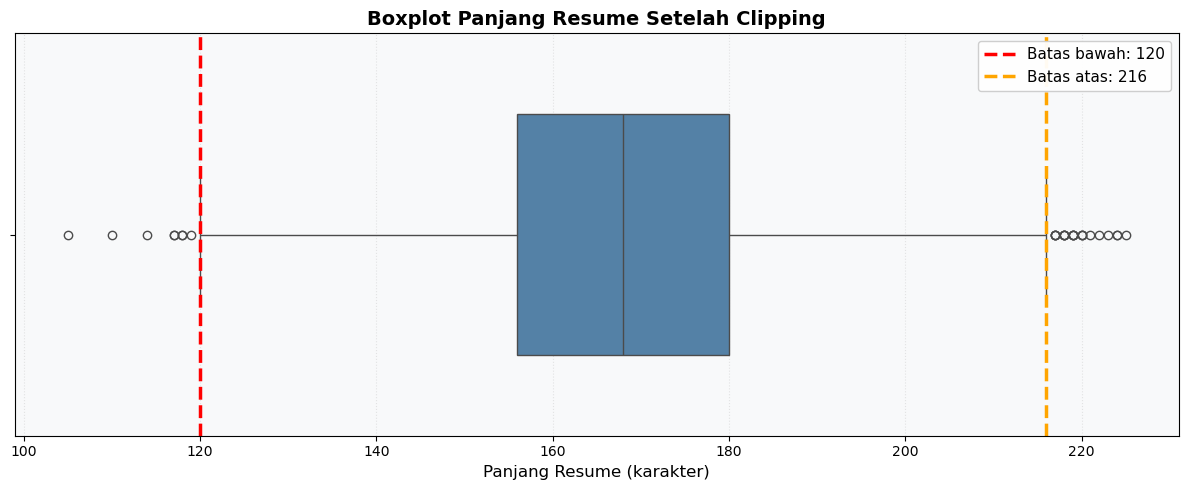


📊 ANALISIS OUTLIER
Total data: 10000
Jumlah outlier: 29
Persentase outlier: 0.29%

📈 STATISTIK DESKRIPTIF:
Min: 105
Max: 225
Mean: 168.55
Median: 168
Std Dev: 17.03



In [107]:
# ============================================================
# Visualisasi Outlier — Boxplot Resume Length (HORIZONTAL)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Pastikan data sudah tersedia
# ============================================================
# Jika belum ada, load atau generate data sample
# merged_df = pd.read_csv('your_data.csv')

# ============================================================
# Hitung IQR untuk menentukan batas outlier
# ============================================================
Q1 = merged_df['resume_len'].quantile(0.25)
Q3 = merged_df['resume_len'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.0f}")
print(f"Q3: {Q3:.0f}")
print(f"IQR: {IQR:.0f}")
print(f"Batas bawah: {lower_bound:.0f}")
print(f"Batas atas: {upper_bound:.0f}")

# ============================================================
# VISUALISASI BOXPLOT HORIZONTAL
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

# Boxplot HORIZONTAL (gunakan parameter 'x' bukan 'y')
sns.boxplot(x=merged_df['resume_len'], color="steelblue", ax=ax, width=0.6)

# Garis batas outlier VERTIKAL (karena boxplot horizontal)
ax.axvline(lower_bound, color='red', linestyle='--', linewidth=2.5, 
           label=f'Batas bawah: {lower_bound:.0f}')
ax.axvline(upper_bound, color='orange', linestyle='--', linewidth=2.5, 
           label=f'Batas atas: {upper_bound:.0f}')

# Judul dan label
ax.set_title("Boxplot Panjang Resume Setelah Clipping", fontsize=14, fontweight='bold')
ax.set_xlabel("Panjang Resume (karakter)", fontsize=12)

# Grid untuk kemudahan membaca
ax.grid(axis='x', alpha=0.3, linestyle=':')

# Legend
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)

# Set background
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

# ============================================================
# INFORMASI OUTLIER
# ============================================================
outliers = merged_df[(merged_df['resume_len'] < lower_bound) | 
                      (merged_df['resume_len'] > upper_bound)]

print(f"\n{'='*60}")
print(f"📊 ANALISIS OUTLIER")
print(f"{'='*60}")
print(f"Total data: {len(merged_df)}")
print(f"Jumlah outlier: {len(outliers)}")
print(f"Persentase outlier: {len(outliers)/len(merged_df)*100:.2f}%")
print(f"\n📈 STATISTIK DESKRIPTIF:")
print(f"Min: {merged_df['resume_len'].min():.0f}")
print(f"Max: {merged_df['resume_len'].max():.0f}")
print(f"Mean: {merged_df['resume_len'].mean():.2f}")
print(f"Median: {merged_df['resume_len'].median():.0f}")
print(f"Std Dev: {merged_df['resume_len'].std():.2f}")
print(f"{'='*60}\n")

In [98]:
# ============================================================
# Sampel Data Outlier
# ============================================================
print("=== Contoh Resume yang Terdeteksi Outlier ===")
print(outliers[['resume_id', 'job_role', 'category', 'resume_len']]
      .sort_values('resume_len', ascending=False)
      .head(10)
      .to_string(index=False))

=== Contoh Resume yang Terdeteksi Outlier ===
resume_id                  job_role           category  resume_len
  r004213        solutions engineer         technology         225
  r002099    clinical lab scientist         healthcare         224
  r005772    clinical lab scientist         healthcare         224
  r005196    clinical lab scientist         healthcare         223
  r002064     clinical data manager         healthcare         222
  r005914 technical account manager         technology         221
  r006810 technical account manager         technology         220
  r006099     agricultural engineer agriculture & food         220
  r003126    clinical lab scientist         healthcare         220
  r001223     clinical data manager         healthcare         219


In [99]:
# Cek outlier setelah clipping
merged_df['resume_len_clipped'] = np.clip(merged_df['resume_len'], lower_bound, upper_bound)

outliers_after = merged_df[
    (merged_df['resume_len_clipped'] < lower_bound) |
    (merged_df['resume_len_clipped'] > upper_bound)
]

print(f"Jumlah outlier setelah clipping: {len(outliers_after)}")

Jumlah outlier setelah clipping: 0


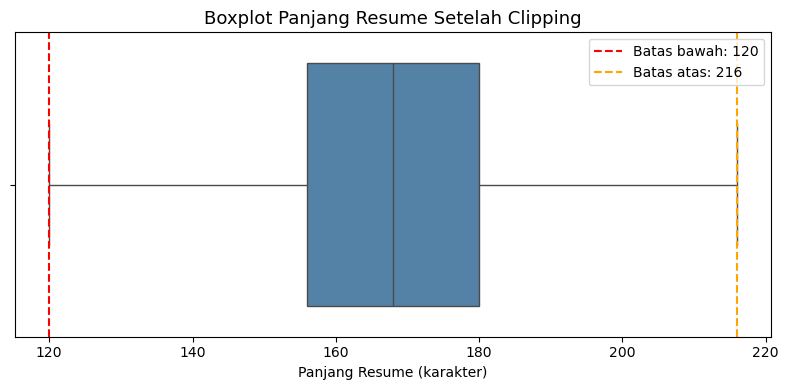

In [100]:
plt.figure(figsize=(8, 4))

# Boxplot setelah clipping (warna biru)
sns.boxplot(
    x=merged_df['resume_len_clipped'],
    color="steelblue"
)

# Garis batas tetap ditampilkan
plt.axvline(lower_bound, color='red', linestyle='--', label=f'Batas bawah: {lower_bound:.0f}')
plt.axvline(upper_bound, color='orange', linestyle='--', label=f'Batas atas: {upper_bound:.0f}')

plt.title("Boxplot Panjang Resume Setelah Clipping", fontsize=13)
plt.xlabel("Panjang Resume (karakter)")
plt.legend()

plt.tight_layout()
plt.show()

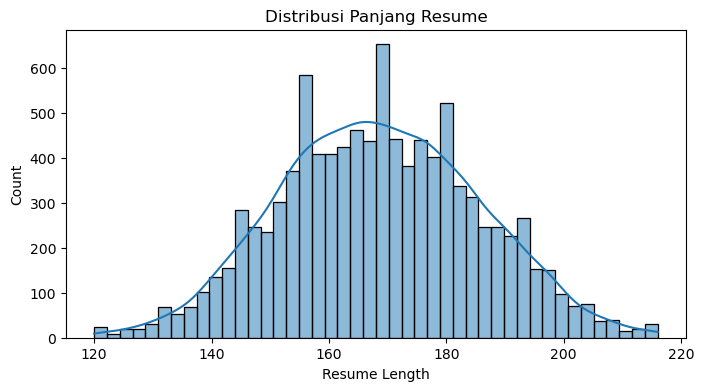

       resume_len_clipped  skills_count
count        10000.000000  10000.000000
mean           168.545400      9.495300
std             16.994706      1.108829
min            120.000000      8.000000
25%            156.000000      9.000000
50%            168.000000      9.000000
75%            180.000000     10.000000
max            216.000000     11.000000


In [101]:
# Histogram + KDE
plt.figure(figsize=(8,4))
sns.histplot(merged_df['resume_len_clipped'], kde=True)
plt.title("Distribusi Panjang Resume")
plt.xlabel("Resume Length")
plt.show()

# Statistik deskriptif
print(merged_df[['resume_len_clipped','skills_count']].describe())

In [102]:
# Jumlah unique value tiap kolom
print("=== Jumlah Unique Value per Kolom ===")
for col in merged_df.columns:
    if col in ['skills', 'required_skills']:
        # For list columns, count unique lists
        print(f"{col}: {merged_df[col].apply(tuple).nunique()}")
    else:
        print(f"{col}: {merged_df[col].nunique()}")

=== Jumlah Unique Value per Kolom ===
resume_id: 10000
resume_text: 10000
skills: 10000
job_role: 324
education: 257
category: 42
required_skills: 324
education_requirement: 245
resume_len: 112
skills_count: 4
resume_len_clipped: 97


In [103]:
# Melihat semua skill unik
#unique_skills = merged_df['skills'].explode().dropna().unique()
#print(unique_skills)


In [104]:
### mau membuat grouping untuk skill : hard skill dan soft skill

In [105]:
# Jumlah skill tiap resume & required_skills tiap lowongan
merged_df['skills_count']     = merged_df['skills'].apply(len)
merged_df['req_skills_count'] = merged_df['required_skills'].apply(len)

print("=== Statistik Jumlah Skill per Resume ===")
print(merged_df['skills_count'].describe())
print()
print("=== Statistik Jumlah Required Skills per Lowongan ===")
print(merged_df['req_skills_count'].describe())

=== Statistik Jumlah Skill per Resume ===
count    10000.000000
mean         9.495300
std          1.108829
min          8.000000
25%          9.000000
50%          9.000000
75%         10.000000
max         11.000000
Name: skills_count, dtype: float64

=== Statistik Jumlah Required Skills per Lowongan ===
count    10000.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: req_skills_count, dtype: float64


In [106]:
# Top 10 skill yang paling banyak dimiliki pelamar
all_candidate_skills = [s for lst in merged_df['skills'] for s in lst]
top_candidate_skills = Counter(all_candidate_skills).most_common(10)

print("=== Top 10 Skill Pelamar ===")
for skill, count in top_candidate_skills:
    print(f"{skill:<30} : {count}")

# Visualisasi
skill_names  = [s[0] for s in top_candidate_skills]
skill_counts = [s[1] for s in top_candidate_skills]

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(x=skill_counts, y=skill_names, palette="Blues_r", ax=ax)

# Label angka di ujung setiap bar
for i, (bar, count) in enumerate(zip(ax.patches, skill_counts)):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va='center', ha='left', fontsize=10, color='#185FA5'
    )

ax.set_title("Top 10 Skill Paling Banyak Dimiliki Pelamar", fontsize=13, pad=12)
ax.set_xlabel("Frekuensi")
ax.set_ylabel("Skill")
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(skill_counts) * 1.15)  # beri ruang untuk label angka
plt.tight_layout()
plt.show()

NameError: name 'Counter' is not defined

In [ ]:
merged_df = pd.read_csv("cleaned_dataset.csv")
# Kolom skills tersimpan sebagai string "['python', 'sql']" → ubah ke list
merged_df['skills']          = merged_df['skills'].apply(ast.literal_eval)
merged_df['required_skills'] = merged_df['required_skills'].apply(ast.literal_eval)

In [ ]:
# Distribusi kategori pekerjaan (visualisasi)
category_counts = merged_df['category'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="mako")
plt.title("Distribusi Kategori Pekerjaan", fontsize=13)
plt.xlabel("Jumlah Pelamar")
plt.ylabel("Kategori")
plt.tight_layout()
plt.show()

print("Jumlah kategori unik :", merged_df['category'].nunique())

In [ ]:
# Top 10 job role terbanyak
job_role_counts = merged_df['job_role'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=job_role_counts.values, y=job_role_counts.index, palette="rocket_r")
plt.title("Top 10 Job Role Terbanyak", fontsize=13)
plt.xlabel("Jumlah Pelamar")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 education requirement yang paling sering muncul
# Warna netral untuk semua bar, kecuali yang tertinggi diberi aksen
edu_counts = merged_df['education_requirement'].value_counts().head(10)

colors = ['#378ADD' if i == 0 else '#B5D4F4' for i in range(len(edu_counts))]

plt.figure(figsize=(10, 6))
sns.barplot(x=edu_counts.values, y=edu_counts.index, palette=colors)
plt.title("Top 10 Education Requirement Lowongan", fontsize=13)
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Education Requirement")

# Tambahkan label nilai di ujung bar tertinggi
plt.text(edu_counts.values[0] + 5, 0,
         str(edu_counts.values[0]),
         va='center', fontsize=10, fontweight='bold', color='#185FA5')

plt.tight_layout()
plt.show()

In [ ]:
# Cek kesesuaian education pelamar vs lowongan
merged_df['education_match'] = merged_df['education'] == merged_df['education_requirement']

match_count   = merged_df['education_match'].sum()
nomatch_count = (~merged_df['education_match']).sum()
match_rate    = merged_df['education_match'].mean() * 100

print("=== Kesesuaian Education Pelamar vs Lowongan ===")
print(f"Match       : {match_count} pelamar")
print(f"Tidak match : {nomatch_count} pelamar")
print(f"Match rate  : {match_rate:.2f}%")

# Visualisasi barchart kesesuaian education
labels = ['Match', 'Tidak Match']
values = [match_count, nomatch_count]
colors = ["#7BACDE", '#378ADD']

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor='none')

# Label jumlah + persentase di dalam bar (bukan di atas)
for bar, val in zip(bars, values):
    pct = val / len(merged_df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 300,
            f"{val:,}\n({pct:.1f}%)",
            ha='center', va='top', fontsize=10,
            color='white', fontweight='bold')

ax.set_title("Kesesuaian Education Pelamar vs Lowongan", fontsize=13, pad=12)
ax.set_ylabel("Jumlah Pelamar")
ax.set_ylim(0, max(values) * 1.1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
soft_skills_set = {
    'communication', 'teamwork', 'leadership', 'problem solving',
    'time management', 'adaptability', 'critical thinking',
    'creativity', 'work ethic', 'collaboration'
}

hard_skills_set = {
    'python', 'java', 'sql', 'machine learning', 'data analysis',
    'excel', 'tableau', 'power bi', 'c++', 'html', 'css',
    'deep learning', 'nlp', 'statistics'
}

In [ ]:
soft_skills_set = {
    'communication', 'teamwork', 'leadership', 'problem solving',
    'time management', 'adaptability', 'critical thinking',
    'creativity', 'work ethic', 'collaboration'
}

hard_skills_set = {
    'python', 'java', 'sql', 'machine learning', 'data analysis',
    'excel', 'tableau', 'power bi', 'c++', 'html', 'css',
    'deep learning', 'nlp', 'statistics'
}

# Re-create columns lost after reloading merged_df from CSV in cell 8c2c2e2a
# Ensure 'resume_len' is present
merged_df['resume_len'] = merged_df['resume_text'].apply(lambda x: len(x))

# Ensure 'skills_count' and 'req_skills_count' are present
merged_df['skills_count'] = merged_df['skills'].apply(len)
merged_df['req_skills_count'] = merged_df['required_skills'].apply(len)

# Re-calculate bounds for resume_len_clipped
Q1  = merged_df['resume_len'].quantile(0.25)
Q3  = merged_df['resume_len'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ensure 'resume_len_clipped' is present
merged_df['resume_len_clipped'] = np.clip(merged_df['resume_len'], lower_bound, upper_bound)

# Ensure 'education_match' is present
merged_df['education_match'] = merged_df['education'] == merged_df['education_requirement']

# Create soft_skills_count and hard_skills_count
merged_df['soft_skills_count'] = merged_df['skills'].apply(lambda x: len(set(x).intersection(soft_skills_set)))
merged_df['hard_skills_count'] = merged_df['skills'].apply(lambda x: len(set(x).intersection(hard_skills_set)))

df_model = merged_df[[
    'resume_len_clipped',
    'skills_count',
    'req_skills_count',
    'soft_skills_count',
    'hard_skills_count',
    'education',
    'category',
    'education_match'
]].copy()

# Tambahan fitur penting
df_model['skill_gap'] = df_model['skills_count'] - df_model['req_skills_count']
df_model['skill_ratio'] = df_model['skills_count'] / (df_model['req_skills_count'] + 1)

In [ ]:
df_model = pd.get_dummies(df_model, columns=['education', 'category'], drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'resume_len_clipped',
    'skills_count',
    'req_skills_count',
    'soft_skills_count',
    'hard_skills_count',
    'skill_gap',
    'skill_ratio'
]

df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop('education_match', axis=1)
y = df_model['education_match']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

In [ ]:
import sys
import subprocess

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop('education_match', axis=1)
y = df_model['education_match']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)